In [1]:
import numpy as np
import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.run_normalization(feat_key='hvgs')
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)
ds.run_marker_search(group_key='RNA_leiden_cluster')

Downloading bucket files: 31491651 / 31491651 complete

Downloading bytes: 31491651 / 31491651 complete

Computing RNA feature statistics: 102 / 102 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

...

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 150 / 150 complete

Finding markers: 1 / 1 complete

In [2]:
markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers[
    [
        'feature_name',
        'score',
        'frac_exp',
        'fold_change',
        'auc',
        'p_value',
        'p_value_adjusted',
    ]
].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.63014,0.23897,11.23353,0.60722,3.006081e-102,2.134318e-100
1,ANKRD55,0.56039,0.14821,14.07863,0.56821,2.967029e-68,1.042437e-66
2,TSHZ2,0.52660,0.32057,5.25961,0.63187,1.698238e-107,1.258173e-105
3,CHRM3-AS2,0.49366,0.38634,7.04237,0.66454,2.218491e-145,2.724547e-143
4,FHIT,0.47692,0.62614,9.37308,0.77649,2.879275e-280,1.453714e-277
5,TCEA3,0.47447,0.20649,6.08420,0.58524,1.890931e-66,6.428221e-65
6,CMTM8,0.46970,0.30558,4.65390,0.61841,5.427940e-83,2.835007e-81
7,AC005842.1,0.46489,0.15654,6.60009,0.56661,2.783421e-55,6.987771e-54
8,EPHX2,0.44346,0.39384,6.62144,0.66375,6.595098e-137,7.250353e-135
9,MAN1C1,0.42478,0.31307,4.47426,0.61797,1.859002e-77,8.227894e-76


Aggregating marker values per group: 2 / 2 complete

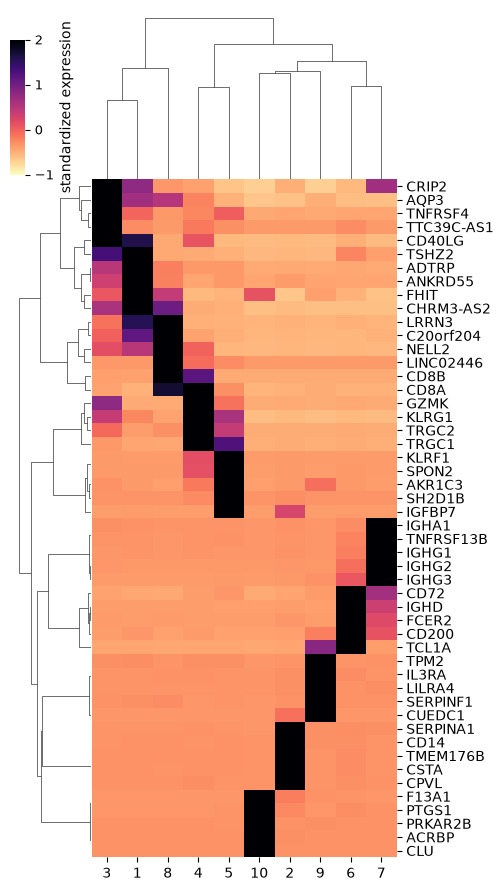

In [3]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9),
)

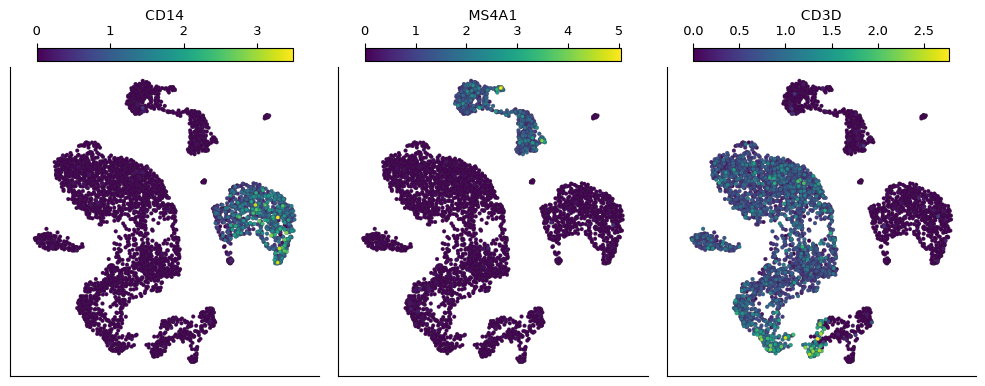

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)

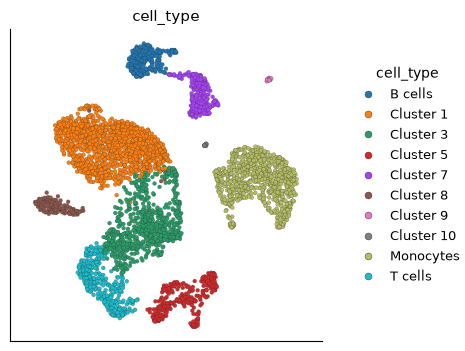

In [5]:
cluster_ids = ds.cells.fetch_all('RNA_leiden_cluster')
unique = sorted(
    {str(c) for c in cluster_ids},
    key=lambda x: (0, int(x)) if x.isdigit() else (1, x),
)

markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)

label_map = {c: f'Cluster {c}' for c in unique}
for gene, name in [('CD14', 'Monocytes'), ('MS4A1', 'B cells'), ('CD3D', 'T cells')]:
    hit = markers[markers['feature_name'].astype(str) == gene]
    if hit.empty:
        continue
    cid = str(hit.sort_values('score', ascending=False).iloc[0]['group_id'])
    label_map[cid] = name

labels = np.array([label_map[str(c)] for c in cluster_ids], dtype=object)
ds.cells.insert(column_name='cell_type', values=labels, overwrite=True)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='cell_type',
)

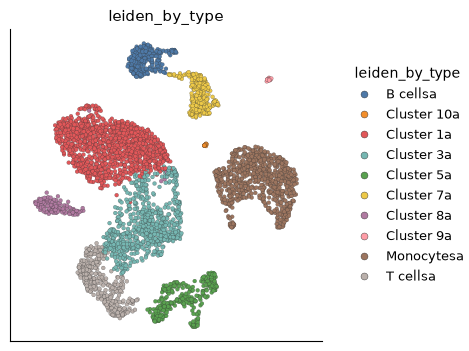

In [6]:
ds.smart_label(
    to_relabel='RNA_leiden_cluster',
    base_label='cell_type',
    new_col_name='leiden_by_type',
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='leiden_by_type',
)